# Clustering the College data
We implement K-means before comparing with scikit-learn, then examine sensitivity to seeds, scaling, and K.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/15-clustering/'
for _name in ['College.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

college=pd.read_csv('College.csv').rename(columns={'Unnamed: 0':'College'})
features=['Apps','Accept','Enroll','Top10perc','F.Undergrad','Outstate','Room.Board','PhD','S.F.Ratio','perc.alumni','Expend','Grad.Rate']
X=StandardScaler().fit_transform(college[features])
X.shape

(777, 12)

## K-means from the objective
The assignment step chooses the nearest center; the update step replaces each center by its assigned mean.

In [2]:
def assign(X, centers):
    dist2=((X[:,None,:]-centers[None,:,:])**2).sum(axis=2)
    labels=dist2.argmin(axis=1)
    return labels, dist2[np.arange(len(X)),labels].sum()

def kmeans_from_scratch(X,K,seed=0,max_iter=200):
    rng=np.random.default_rng(seed)
    centers=X[rng.choice(len(X),K,replace=False)].copy()
    history=[]
    for step in range(max_iter):
        labels,wcss=assign(X,centers); history.append(wcss)
        new=np.vstack([X[labels==k].mean(axis=0) if np.any(labels==k) else centers[k] for k in range(K)])
        if np.allclose(new,centers): break
        centers=new
    labels,wcss=assign(X,centers)
    return centers,labels,wcss,history

runs=[kmeans_from_scratch(X,3,seed) for seed in range(40)]
centers,labels,wcss,history=min(runs,key=lambda item:item[2])
np.bincount(labels),wcss,history[:5],history[-1]

(array([461,  81, 235]),
 np.float64(5298.492550749856),
 [np.float64(11780.866240526153),
  np.float64(5662.005700689121),
  np.float64(5515.424603316911),
  np.float64(5431.061788304246),
  np.float64(5388.5700283683655)],
 np.float64(5298.492550749856))

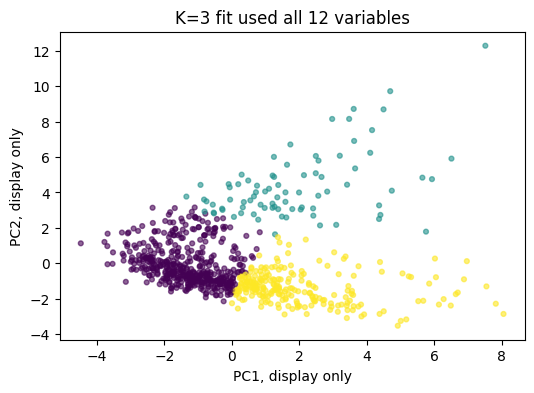

In [3]:
scores=PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(6,4)); plt.scatter(scores[:,0],scores[:,1],c=labels,s=12,alpha=.6)
plt.xlabel('PC1, display only'); plt.ylabel('PC2, display only'); plt.title('K=3 fit used all 12 variables')
plt.show()

## Compare with a production implementation
Scikit-learn uses careful initialization and multiple starts. Labels are arbitrary, so agreement measures must be permutation-invariant.

In [4]:
library=KMeans(n_clusters=3,n_init=40,random_state=26518).fit(X)
{'scratch_wcss':wcss,'library_wcss':library.inertia_,'agreement':adjusted_rand_score(labels,library.labels_)}

{'scratch_wcss': np.float64(5298.492550749856),
 'library_wcss': 5298.492550749856,
 'agreement': 1.0}

In [5]:
rows=[]
for K in range(2,8):
    fit=KMeans(n_clusters=K,n_init=20,random_state=26518).fit(X)
    rows.append((K,fit.inertia_,silhouette_score(X,fit.labels_)))
pd.DataFrame(rows,columns=['K','WCSS','silhouette'])

,K,WCSS,silhouette
0,2,7179.934567,0.271262
1,3,5298.566458,0.275400
2,4,4587.116068,0.215788
3,5,4106.292161,0.201312
4,6,3833.675212,0.182798
5,7,3581.946905,0.169679


## Other ways to cluster the same points
K-means draws straight boundaries because its groups are Voronoi cells. Hierarchical
clustering builds a tree instead of committing to K, and density- or graph-based methods
follow curved shapes.

/opt/homebrew/Caskroom/miniconda/base/envs/sds265/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


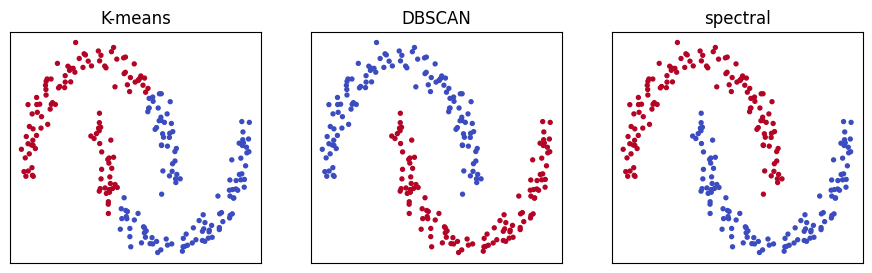

In [6]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, SpectralClustering
from scipy.cluster.hierarchy import dendrogram, linkage

rng = np.random.default_rng(26518)
angle = rng.uniform(0, np.pi, 120)
moons = np.r_[np.c_[np.cos(angle), np.sin(angle)],
              np.c_[1 - np.cos(angle), .48 - np.sin(angle)]] + rng.normal(scale=.07, size=(240, 2))

fits = {'K-means': KMeans(2, n_init=20, random_state=26518).fit_predict(moons),
        'DBSCAN': DBSCAN(eps=.22, min_samples=5).fit_predict(moons),
        'spectral': SpectralClustering(2, affinity='nearest_neighbors', n_neighbors=10,
                                       random_state=26518).fit_predict(moons)}
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (name, labels) in zip(axes, fits.items()):
    ax.scatter(moons[:, 0], moons[:, 1], c=labels, s=8, cmap='coolwarm')
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
plt.show()

### The tree, and what the linkage rule does to it
Two groups joined by a thin bridge, plus two stray points.

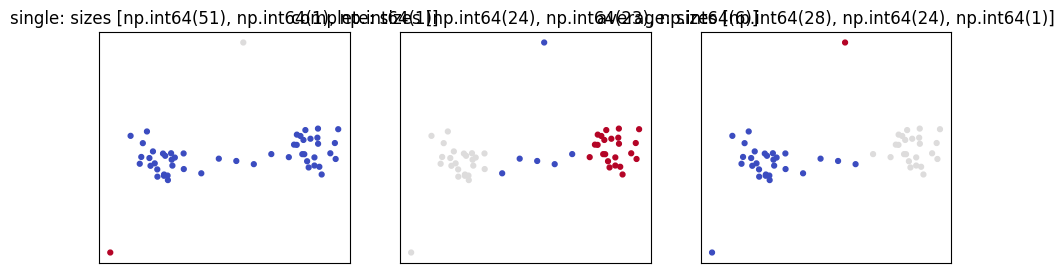

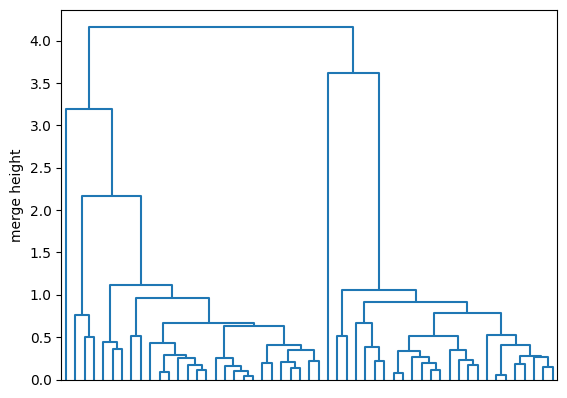

In [7]:
bridge = np.r_[rng.normal([-2.2, 0], .45, (22, 2)),
               rng.normal([2.2, .3], .45, (22, 2)),
               np.c_[np.linspace(-1.5, 1.5, 7), rng.normal(0, .12, 7)],
               [[.2, 3.4], [-3.6, -2.6]]]
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, method in zip(axes, ['single', 'complete', 'average']):
    labels = AgglomerativeClustering(n_clusters=3, linkage=method).fit_predict(bridge)
    ax.scatter(bridge[:, 0], bridge[:, 1], c=labels, s=12, cmap='coolwarm')
    ax.set_title(f'{method}: sizes {sorted(np.bincount(labels))[::-1]}')
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

dendrogram(linkage(bridge, method='average'), no_labels=True, color_threshold=0)
plt.ylabel('merge height'); plt.show()

## Keep the partitioning idea, change the distance
Euclidean distance measures a straight line through the plane. For the moons we instead build a mutual nearest-neighbor graph and measure the shortest route along its edges. We then use that curved distance for both assignment and selection of the representative observation (the medoid).

In [8]:
from matplotlib.collections import LineCollection
from scipy.sparse.csgraph import connected_components, shortest_path
from sklearn.neighbors import kneighbors_graph

def mutual_neighbor_distances(X, n_neighbors=10):
    # Keep an edge only when each endpoint is among the other's neighbors.
    graph = kneighbors_graph(X, n_neighbors, mode='distance', include_self=False)
    graph = graph.minimum(graph.T).tocsr()
    distances = shortest_path(graph, directed=False)
    finite = distances[np.isfinite(distances)]
    # Disconnected pairs have no route. Give them a cost larger than every
    # within-component route so that the medoids occupy different components.
    distances = np.where(np.isfinite(distances), distances, 2 * finite.max())
    n_components = connected_components(graph, directed=False)[0]
    return graph, distances, n_components

def two_medoids(distances, max_iter=50):
    # A deterministic far-apart initialization.
    first = int(np.argmin(distances.sum(axis=1)))
    medoids = np.array([first, int(np.argmax(distances[:, first]))])
    for _ in range(max_iter):
        labels = distances[:, medoids].argmin(axis=1)
        updated = []
        for group in range(2):
            members = np.flatnonzero(labels == group)
            within = distances[np.ix_(members, members)].sum(axis=1)
            updated.append(int(members[np.argmin(within)]))
        updated = np.asarray(updated)
        if np.array_equal(updated, medoids):
            break
        medoids = updated
    return medoids, distances[:, medoids].argmin(axis=1)

def errors_up_to_label_swap(labels, truth):
    return min(np.sum(labels != truth), np.sum((1 - labels) != truth))

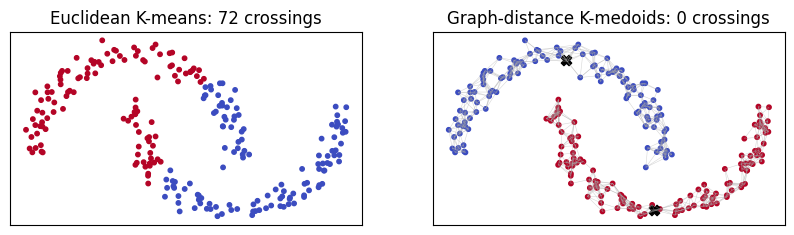

The mutual 10-neighbor graph has 2 connected components.


In [9]:
moon_truth = np.r_[np.zeros(120, dtype=int), np.ones(120, dtype=int)]
euclidean_labels = KMeans(2, n_init=20, random_state=3).fit_predict(moons)
graph, curved_distances, n_components = mutual_neighbor_distances(moons, n_neighbors=10)
medoids, curved_labels = two_medoids(curved_distances)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True, sharey=True)
axes[0].scatter(moons[:, 0], moons[:, 1], c=euclidean_labels, s=10, cmap='coolwarm')
axes[0].set_title(f'Euclidean K-means: {errors_up_to_label_swap(euclidean_labels, moon_truth)} crossings')

rows, cols = graph.nonzero()
segments = np.asarray([[moons[i], moons[j]] for i, j in zip(rows, cols) if i < j])
axes[1].add_collection(LineCollection(segments, colors='0.65', linewidths=.4, alpha=.45))
axes[1].scatter(moons[:, 0], moons[:, 1], c=curved_labels, s=10, cmap='coolwarm')
axes[1].scatter(moons[medoids, 0], moons[medoids, 1], marker='X', c='black', s=55)
axes[1].set_title(f'Graph-distance K-medoids: {errors_up_to_label_swap(curved_labels, moon_truth)} crossings')
for ax in axes:
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
plt.show()
print(f'The mutual 10-neighbor graph has {n_components} connected components.')

### The graph scale is a modeling choice
Too few neighbors can fragment a genuine group. Too many can create shortcuts across the gap. Change `n_neighbors` below and watch both the graph and the fitted partition change. The generating labels are used only to count crossings after fitting.

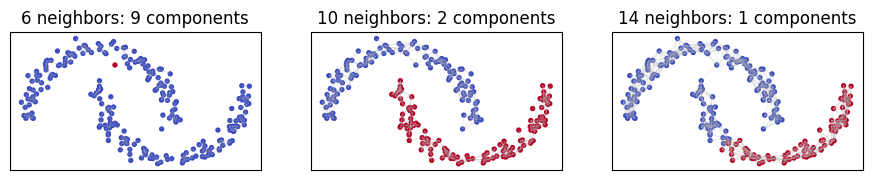

,neighbors,graph components,crossings
0,6,9,119
1,10,2,0
2,14,1,39


In [10]:
rows = []
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=True, sharey=True)
for ax, neighbors in zip(axes, [6, 10, 14]):
    graph_k, distance_k, components_k = mutual_neighbor_distances(moons, neighbors)
    medoids_k, labels_k = two_medoids(distance_k)
    crossings_k = errors_up_to_label_swap(labels_k, moon_truth)
    rows.append((neighbors, components_k, crossings_k))
    graph_rows, graph_cols = graph_k.nonzero()
    edges = np.asarray([[moons[i], moons[j]] for i, j in zip(graph_rows, graph_cols) if i < j])
    ax.add_collection(LineCollection(edges, colors='0.7', linewidths=.35, alpha=.4))
    ax.scatter(moons[:, 0], moons[:, 1], c=labels_k, s=8, cmap='coolwarm')
    ax.set_title(f'{neighbors} neighbors: {components_k} components')
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
plt.show()
pd.DataFrame(rows, columns=['neighbors', 'graph components', 'crossings'])